In [36]:
import math

from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, MCMT, XGate, ZGate
from qiskit.circuit.library import grover_operator
from qiskit.visualization import plot_distribution

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [37]:
def h(x):
    x0, x1, x2, x3 = x
    return (
        x0 ^ x1,
        x1 ^ x2,
        x2 ^ x3,
        x3 ^ x0
    )

solutions = []

for i in range(16):
    x = [(i >> j) & 1 for j in range(4)]
    if h(x) == (1, 1, 0, 0):
        solutions.append(x)

print(solutions)

[[0, 1, 0, 0], [1, 0, 1, 1]]


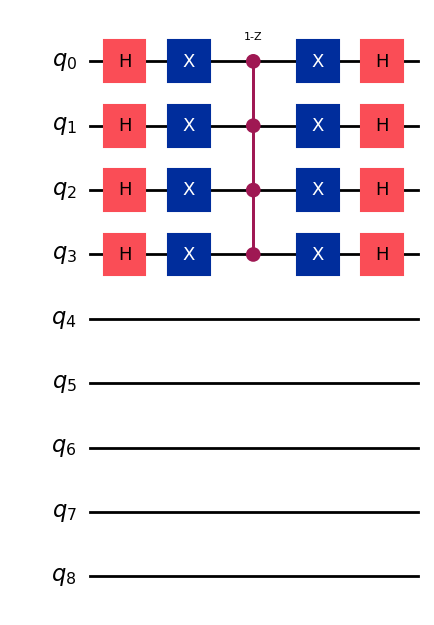

In [38]:
diffuser = QuantumCircuit(9, name="diffuser")

diffuser.h([0, 1, 2, 3])
diffuser.x([0, 1, 2, 3])

diffuser.compose(
    MCMTGate(ZGate(), 3, 1),
    qubits=[0, 1, 2, 3],
    inplace=True
)

diffuser.x([0, 1, 2, 3])
diffuser.h([0, 1, 2, 3])

diffuser.draw(output="mpl", style="iqp")

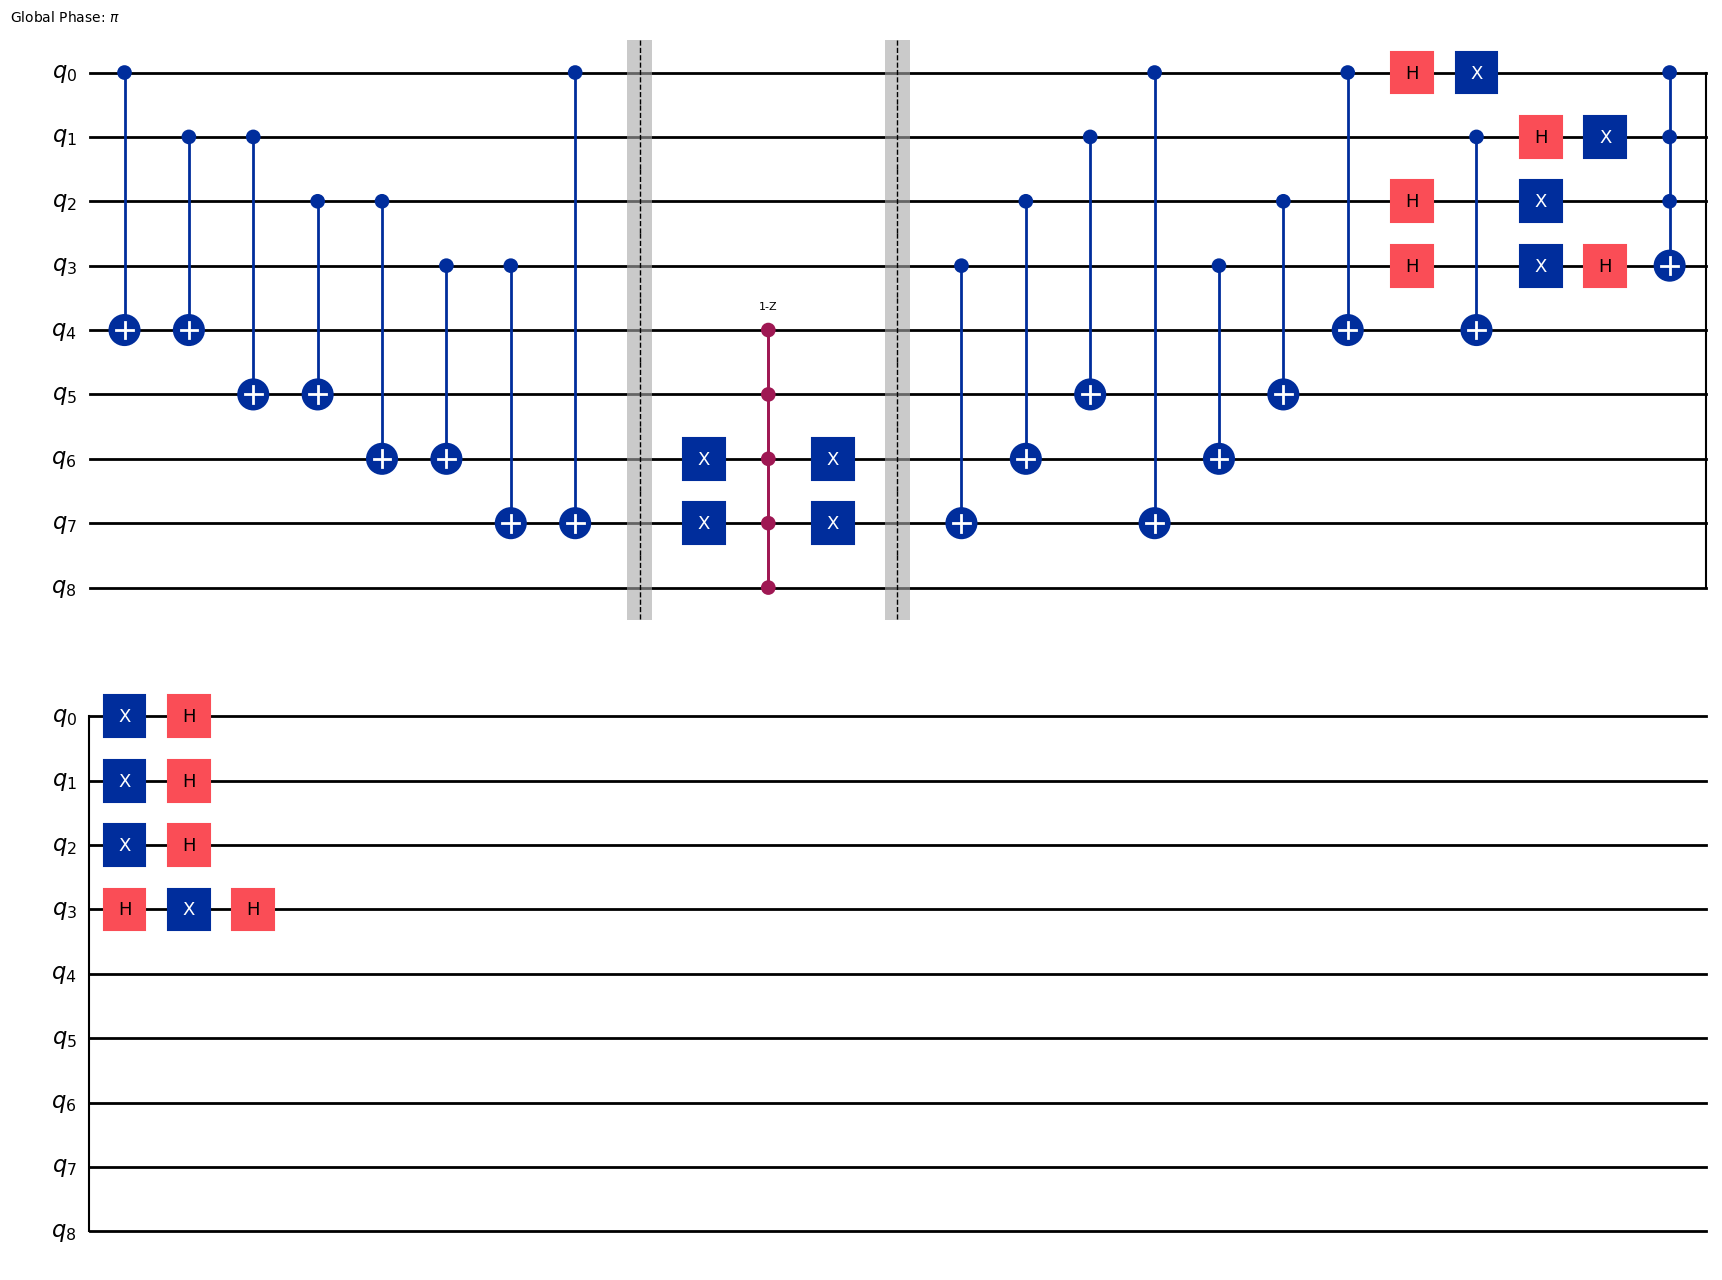

In [39]:
oracle = QuantumCircuit(9, name="oracle")
oracle.cx(0, 4)
oracle.cx(1, 4)

oracle.cx(1, 5)
oracle.cx(2, 5)

oracle.cx(2, 6)
oracle.cx(3, 6)

oracle.cx(3, 7)
oracle.cx(0, 7)

oracle.barrier()

oracle.x(6)
oracle.x(7)

oracle.compose(
    MCMTGate(ZGate(), 4, 1),
    qubits=[4, 5, 6, 7, 8],
    inplace=True
)

oracle.x(6)
oracle.x(7)

oracle.barrier()

oracle.cx(3, 7)
oracle.cx(0, 7)

oracle.cx(2, 6)
oracle.cx(3, 6)

oracle.cx(1, 5)
oracle.cx(2, 5)

oracle.cx(0, 4)
oracle.cx(1, 4)

oracle.draw()

grover_op = grover_operator(
    oracle,
    reflection_qubits=[0, 1, 2, 3]
)
grover_op.draw(output="mpl", style="iqp")

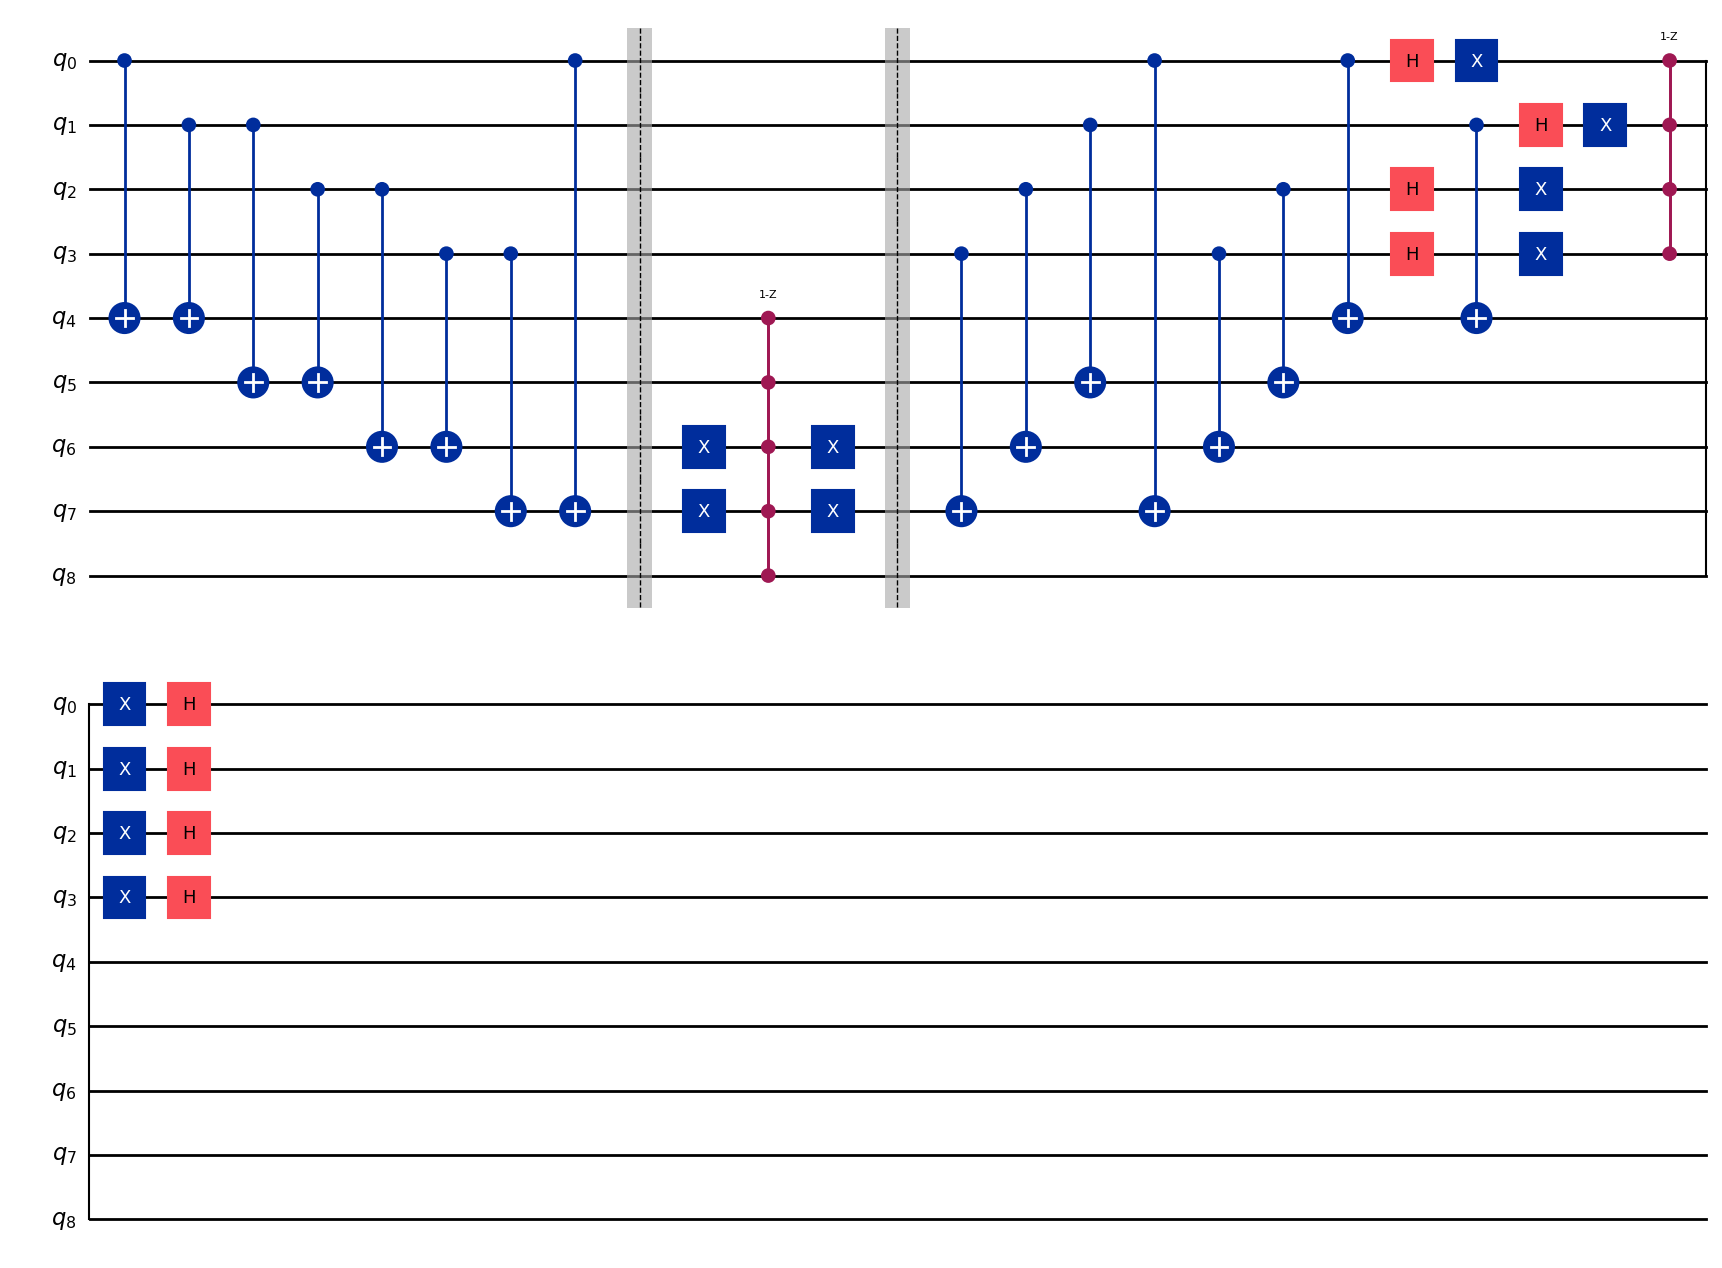

In [40]:
grover_manual = QuantumCircuit(9, name="grover_manual")

grover_manual.compose(oracle, inplace=True)
grover_manual.compose(diffuser, inplace=True)

grover_manual.draw(output="mpl", style="iqp")

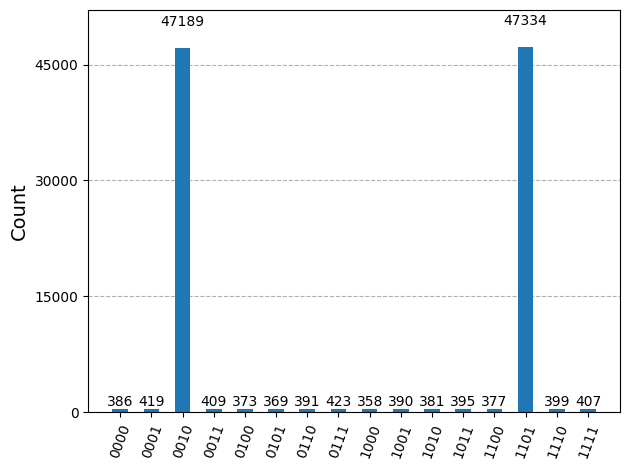

In [46]:
qc = QuantumCircuit(9, 4)

qc.h([0, 1, 2, 3])

for _ in range(2):
    qc.compose(oracle, inplace=True)
    qc.compose(diffuser, inplace=True)

qc.measure([0, 1, 2, 3], [0, 1, 2, 3])

qc.draw(output="mpl", style="iqp")

sampler_simulator = StatevectorSampler()

num_shots = 100000
result = sampler_simulator.run([qc], shots=num_shots).result()

counts = result[0].data.c.get_counts()

plot_histogram(counts)